## GPTS TimeSformer on UWHVF dataset

0. Import necessary packages

In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Glaucoma Test
!ls

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Dataloader import dataloaders
from sklearn.metrics import confusion_matrix, accuracy_score

Mounted at /content/drive
/content/drive/MyDrive/Glaucoma Test
AA_Original_init.py	Rotterdam_OS_Left.csv
aa_weights.npy		Rotterdam_Preprocessing.ipynb
alldata.json		rotterdam_processed_od_format.csv
compute_aa_weights.py	rotterdam_uwhvf_like.json
Dataloader.py		saved_models_GPTS_EarlyInjectionAA
data_preprocessing.py	saved_models_GPTS_LateFusionAA
Execution.ipynb		saved_models_GPTS_noAA
GP_Detection.ipynb	TimeSformer_with_AA.py
Model.py		training_func_earlyinjectionAA.py
__pycache__		training_func_latefusionAA.py
Rotterdam_OD_Right.csv	training_func_noAA.py
Length of prog_labellist, total number of subjects with 3+ frames: 2991
Progressing number of subjects (1): 1769
Data preprocessing complete!
Loaded archetype_weights with shape: (2991, 18)
Total samples: 2991
Train size   : 2392
Test size    : 599


1. Preprocess data with data_preprocessing.py

In [3]:
%run data_preprocessing.py
!python compute_aa_weights.py

Length of prog_labellist, total number of subjects with 3+ frames: 2991
Progressing number of subjects (1): 1769
Data preprocessing complete!
Loaded archetype_weights with shape: (2991, 18)
Length of prog_labellist, total number of subjects with 3+ frames: 2991
Progressing number of subjects (1): 1769
Data preprocessing complete!
Loaded archetype_weights with shape: (2991, 18)
Alpha shape (n_samples, n_archetypes): (2991, 18)
Saved archetype weights to aa_weights.npy


In [4]:
from data_preprocessing import archetype_weights

print("archetype_weights is None:", archetype_weights is None)
if archetype_weights is not None:
    print("archetype_weights.shape:", archetype_weights.shape)


archetype_weights is None: False
archetype_weights.shape: (2991, 18)


2. Set random seed for reproducability

In [5]:
torch.manual_seed(42)
np.random.seed(42)

2. Define Dataset class and DataLoaders with Dataloader.py

In [6]:
%run Dataloader.py

Total samples: 2991
Train size   : 2392
Test size    : 599


3. Define Model

In [7]:
NUM_ARCHETYPES = 18      # must match compute_aa_weights.py
!pip -q install timesformer-pytorch
%run Model.py
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

4. Make a folder to save model at the end of each epoch

In [7]:
!mkdir saved_models_GPTS_noAA
!mkdir saved_models_GPTS_LateFusionAA
!mkdir saved_models_GPTS_EarlyInjectionAA

5. Define optimizer, create instance of model, and enter training/validation loop with training_func.py

In [8]:
%run training_func_noAA.py

Using device: cuda:0
Train dataset size: 2392
Train class counts (0=stable, 1=progressor): 977 1415

BASELINE (No AA) | Fold 1/5
Fold 1 | Epoch 1/100 | train_loss: 1.2201, train_acc: 0.6158 | val_loss: 0.6341, val_acc: 0.6388
Fold 1 | Epoch 2/100 | train_loss: 0.6441, train_acc: 0.6315 | val_loss: 0.6260, val_acc: 0.6660
Fold 1 | Epoch 3/100 | train_loss: 0.6324, train_acc: 0.6628 | val_loss: 0.6273, val_acc: 0.6660
Fold 1 | Epoch 4/100 | train_loss: 0.6206, train_acc: 0.6686 | val_loss: 0.6234, val_acc: 0.6701
Fold 1 | Epoch 5/100 | train_loss: 0.6223, train_acc: 0.6796 | val_loss: 0.6268, val_acc: 0.6597
Fold 1 | Epoch 6/100 | train_loss: 0.6174, train_acc: 0.6707 | val_loss: 0.6142, val_acc: 0.6681
Fold 1 | Epoch 7/100 | train_loss: 0.6092, train_acc: 0.6806 | val_loss: 0.6272, val_acc: 0.6514
Fold 1 | Epoch 8/100 | train_loss: 0.6025, train_acc: 0.6858 | val_loss: 0.6625, val_acc: 0.6200
Fold 1 | Epoch 9/100 | train_loss: 0.6009, train_acc: 0.6916 | val_loss: 0.6145, val_acc: 0.655

In [8]:
%run training_func_latefusionAA.py

Using device: cuda:0
Train dataset size: 2392
Train class counts (0=stable, 1=progressor): 977 1415

Fold 1/5
Fold 1 | Train size: 1913 | Val size: 479
Fold 1 | Epoch 1/100 | train_loss: 0.6783, train_acc: 0.5912 | val_loss: 0.6514, val_acc: 0.5908
Fold 1 | Epoch 2/100 | train_loss: 0.6545, train_acc: 0.6325 | val_loss: 0.6250, val_acc: 0.6555
Fold 1 | Epoch 3/100 | train_loss: 0.6481, train_acc: 0.6409 | val_loss: 1.3576, val_acc: 0.5887
Fold 1 | Epoch 4/100 | train_loss: 0.6514, train_acc: 0.6419 | val_loss: 0.6786, val_acc: 0.6117
Fold 1 | Epoch 5/100 | train_loss: 0.6449, train_acc: 0.6430 | val_loss: 0.6303, val_acc: 0.6305
Fold 1 | Epoch 6/100 | train_loss: 0.6378, train_acc: 0.6482 | val_loss: 0.6331, val_acc: 0.6618
Fold 1 | Epoch 7/100 | train_loss: 0.6431, train_acc: 0.6498 | val_loss: 0.6291, val_acc: 0.6451
Fold 1 | Epoch 8/100 | train_loss: 0.6449, train_acc: 0.6424 | val_loss: 0.6154, val_acc: 0.6576
Fold 1 | Epoch 9/100 | train_loss: 0.6455, train_acc: 0.6351 | val_loss:

In [9]:
%run training_func_earlyinjectionAA.py

Using device: cuda:0
Train dataset size: 2392
Train class counts (0=stable, 1=progressor): 977 1415

Fold 1/5
Fold 1 | Train size: 1913 | Val size: 479
Fold 1 | Epoch 1/100 | train_loss: 1.1365, train_acc: 0.6064 | val_loss: 0.6336, val_acc: 0.6347
Fold 1 | Epoch 2/100 | train_loss: 0.6383, train_acc: 0.6487 | val_loss: 0.6875, val_acc: 0.6054
Fold 1 | Epoch 3/100 | train_loss: 0.6254, train_acc: 0.6587 | val_loss: 0.6366, val_acc: 0.6367
Fold 1 | Epoch 4/100 | train_loss: 0.6255, train_acc: 0.6597 | val_loss: 0.6192, val_acc: 0.6639
Fold 1 | Epoch 5/100 | train_loss: 0.6183, train_acc: 0.6644 | val_loss: 0.6151, val_acc: 0.6764
Fold 1 | Epoch 6/100 | train_loss: 0.6139, train_acc: 0.6864 | val_loss: 0.6106, val_acc: 0.6555
Fold 1 | Epoch 7/100 | train_loss: 0.6092, train_acc: 0.6801 | val_loss: 0.6165, val_acc: 0.6722
Fold 1 | Epoch 8/100 | train_loss: 0.6024, train_acc: 0.6926 | val_loss: 0.6091, val_acc: 0.6618
Fold 1 | Epoch 9/100 | train_loss: 0.6008, train_acc: 0.6963 | val_loss:

6. Run model with test data


===== Baseline (No AA) =====
Accuracy : 0.6828
Precision: 0.7470
Recall   : 0.7006
F1-score : 0.7230
AUC      : 0.7274


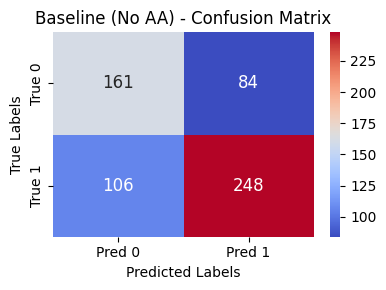

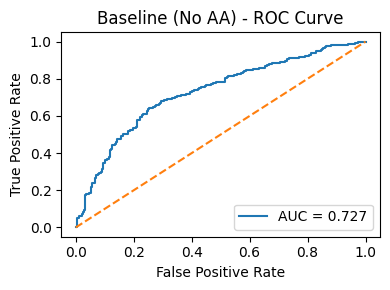


===== Late Fusion AA =====
Accuracy : 0.6745
Precision: 0.7252
Recall   : 0.7232
F1-score : 0.7242
AUC      : 0.7160


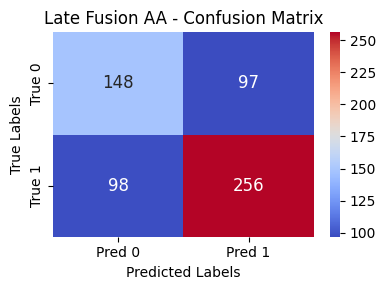

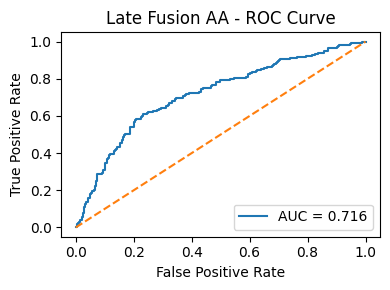


===== Early Injection AA =====
Accuracy : 0.6177
Precision: 0.6485
Recall   : 0.7712
F1-score : 0.7045
AUC      : 0.6242


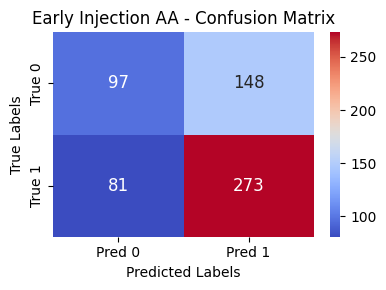

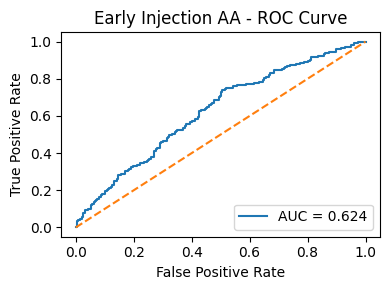

In [14]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import seaborn as sns
import matplotlib.pyplot as plt

from Dataloader import test_dataset
from Model import GPTS_NoAA, GPTS_LateFusionAA, GPTS_EarlyInjectionAA

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 5

def evaluate_on_test(model, checkpoint_path: str, title: str):
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.to(device)
    model.eval()

    true_labels, pred_labels, prob_scores = [], [], []

    with torch.no_grad():
        for data, aa_w, label in test_loader:
            data  = data.to(device).float()
            aa_w  = aa_w.to(device).float()
            label = label.unsqueeze(1).to(device)

            # forward
            if isinstance(model, GPTS_NoAA):
                logits = model(data)
            else:
                logits = model(data, aa_w)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).cpu().numpy().astype(int)

            prob_scores.extend(probs.cpu().numpy().flatten())
            pred_labels.extend(preds.flatten())
            true_labels.extend(label.cpu().numpy().flatten())

    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)
    prob_scores = np.array(prob_scores)

    acc  = accuracy_score(true_labels, pred_labels)
    prec = precision_score(true_labels, pred_labels, zero_division=0)
    rec  = recall_score(true_labels, pred_labels, zero_division=0)
    f1   = f1_score(true_labels, pred_labels, zero_division=0)

    try:
        auc = roc_auc_score(true_labels, prob_scores)
    except ValueError:
        auc = float("nan")

    print(f"\n===== {title} =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm',
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'],
                annot_kws={"size": 12})
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"{title} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # ROC curve
    if not np.isnan(auc):
        fpr, tpr, _ = roc_curve(true_labels, prob_scores)
        plt.figure(figsize=(4, 3))
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{title} - ROC Curve")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()


# ---- Evaluate baseline ----
baseline_model = GPTS_NoAA()
evaluate_on_test(
    baseline_model,
    "./saved_models_GPTS_noAA/best_model_for_test.pth",
    "Baseline (No AA)"
)

# ---- Evaluate late fusion AA ----
latefusion_model = GPTS_LateFusionAA(num_archetypes=18)
evaluate_on_test(
    latefusion_model,
    "./saved_models_GPTS_LateFusionAA/best_model_for_test.pth",
    "Late Fusion AA"
)

# ---- Evaluate early injection AA ----
earlyinject_model = GPTS_EarlyInjectionAA(num_archetypes=18)
evaluate_on_test(
    earlyinject_model,
    "./saved_models_GPTS_EarlyInjectionAA/best_model_for_test.pth",
    "Early Injection AA"
)